In [13]:
import pandas as pd
import numpy as np

In [14]:
df = pd.read_csv(f"data-01-processed/ridge_regression_train.csv", index_col=[0])

df

,temp,atemp,hum,wind,temp_sq,hum_sq,wind_sq,temp_x_hum,temp_x_wind,atemp_x_hum,...,dayofyear,sin_doy_1,cos_doy_1,sin_doy_2,cos_doy_2,sin_doy_3,cos_doy_3,wcond_2,wcond_3,count
1,9.1,13.2,79.78,10.43,82.81,6364.8484,108.7849,725.998,94.913,1053.096,...,1,1.721336e-02,0.999852,3.442161e-02,0.999407,5.161967e-02,0.998667,True,False,982
2,9.9,12.7,68.91,16.16,98.01,4748.5881,261.1456,682.209,159.984,875.157,...,2,3.442161e-02,0.999407,6.880243e-02,0.997630,1.031017e-01,0.994671,True,False,797
3,3.1,4.5,43.29,16.14,9.61,1874.0241,260.4996,134.199,50.034,194.805,...,3,5.161967e-02,0.998667,1.031017e-01,0.994671,1.543088e-01,0.988023,False,False,1351
4,3.2,5.6,58.45,10.42,10.24,3416.4025,108.5764,187.040,33.344,327.320,...,4,6.880243e-02,0.997630,1.372788e-01,0.990532,2.051045e-01,0.978740,False,False,1559
5,4.3,6.5,43.26,12.15,18.49,1871.4276,147.6225,186.018,52.245,281.190,...,5,8.596480e-02,0.996298,1.712931e-01,0.985220,2.553533e-01,0.966848,False,False,1597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,8.3,11.4,75.49,12.25,68.89,5698.7401,150.0625,626.567,101.675,860.586,...,361,-6.880243e-02,0.997630,-1.372788e-01,0.990532,-2.051045e-01,0.978740,True,False,1161
362,7.3,9.0,49.89,19.11,53.29,2489.0121,365.1921,364.197,139.503,449.010,...,362,-5.161967e-02,0.998667,-1.031017e-01,0.994671,-1.543088e-01,0.988023,False,False,2301
363,5.2,8.2,56.84,7.76,27.04,3230.7856,60.2176,295.568,40.352,466.088,...,363,-3.442161e-02,0.999407,-6.880243e-02,0.997630,-1.031017e-01,0.994671,False,False,2421
364,7.8,10.9,63.03,8.73,60.84,3972.7809,76.2129,491.634,68.094,687.027,...,364,-1.721336e-02,0.999852,-3.442161e-02,0.999407,-5.161967e-02,0.998667,False,False,2995


# Clustering

In [27]:
from fast_hdbscan import HDBSCAN, PLSCAN
from sklearn.mixture import GaussianMixture

In [32]:
df["label"] = GaussianMixture(
    n_components=6    
).fit_predict(np.ascontiguousarray(df.drop(columns = ["count"]).to_numpy()))

In [33]:
df["label"].value_counts()

label
5    74
0    73
3    58
4    56
2    53
1    51
Name: count, dtype: int64

# Seaborn

In [34]:
import seaborn as sns

/tmp/ipykernel_37769/863003395.py:1: UserWarning: The palette list has more values (10) than needed (6), which may not be intended.
  sns.catplot(


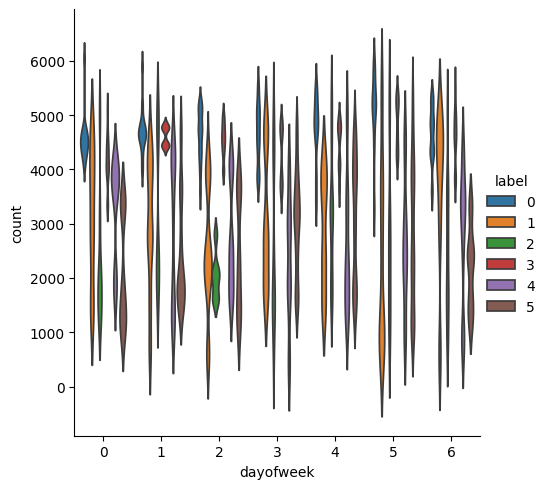

In [35]:
sns.catplot(
    df,
    x = "dayofweek",
    y = "count",
    kind = "violin",
    hue="label",
    inner = None,
    bw_adjust = 0.5,
    palette=sns.color_palette()
)